In [2]:
import sys
import astropy
import astroquery.simbad
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyarrow
import pyvo
from astroquery.simbad import Simbad
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
from collections import Counter
import timeit
import matplotlib.pyplot as plt
import pandas
import scipy

In [3]:
input = ascii.read("./input/HPIC_LC4_combined_d50.txt")
pscomppars = ascii.read("pscomppars.txt")

In [4]:
pd_input = input.to_pandas()
pd_pscomppars = pscomppars.to_pandas()

### 2D coordinate matching

In [5]:
max_sep = 0.1*u.arcsec

In [6]:
coords_input = SkyCoord(ra=input["ra"], dec=input["dec"], unit="deg")
coords_nea = SkyCoord(ra=pscomppars["ra"], dec=pscomppars["dec"], unit="deg")

idx, sep2d, _ = coords_input.match_to_catalog_sky(coords_nea)

mask = sep2d < max_sep

matches = pd_input[mask].assign(hostname=pd_pscomppars["hostname"].to_numpy()[idx[mask]])
matches

,star_name,sy_dist,st_spectype,st_rad,st_teff,st_mass,st_age,ra,dec,sy_vmag,sy_jmag,sy_hmag,sy_kmag,known_binary_fl,gaia_binary_fl,WDSsep,wds_deltamag,hostname
13,TIC 229540730,38.774719,K4-III,41.796402,4043.0,0.632283,null,222.676488,74.155550,null,null,null,null,1,0,212.3,10.55,bet UMi
137,TIC 318686860,3.786000,M3.5V,0.362232,3150.0,0.293518,null,111.852100,5.225800,8.576388359069824,8.576388359069824,8.576388359069824,8.576388359069824,1,1,0.2,null,GJ 273
423,TIC 311407476,29.489826,K5,0.878874,4388.0,0.686206,null,264.294879,27.896378,null,null,null,null,1,0,0.2,0.5899999999999999,HIP 86221


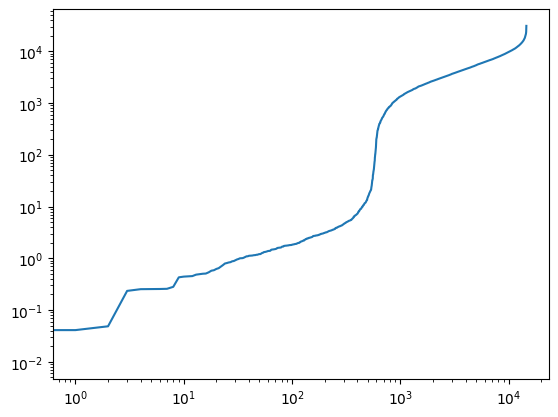

In [7]:
plt.loglog(np.sort(sep2d.to(u.arcsec)))

In [8]:
self_matches_ids, sep_self, _ = coords_input.match_to_catalog_sky(coords_input, nthneighbor=2)
self_matches = np.sum(sep_self < max_sep)
self_matches

np.int64(8)

In [9]:
# matches

### 3D coordinate matching


In [10]:
sys.float_info.epsilon

2.220446049250313e-16

<Quantity 6.72638351e+10 m>

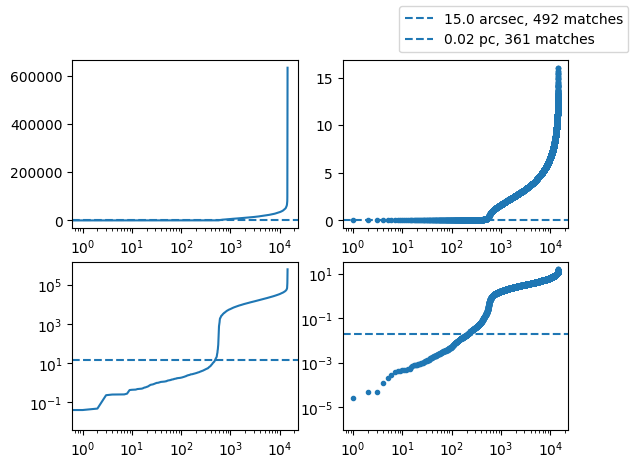

In [11]:
coords_input3d = SkyCoord(
	ra=input["ra"]*u.deg,
	dec=input["dec"]*u.deg,
	distance=input["sy_dist"]*u.pc
)
coords_nea3d = SkyCoord(
	ra=pscomppars["ra"]*u.deg,
	dec=pscomppars["dec"]*u.deg, 
	distance=(pscomppars["sy_dist"]*u.pc).to(u.pc)
)

# can't register smaller than 10^-16 parsec (floating 
idx, sep2d, sep3d = coords_input3d.match_to_catalog_3d(coords_nea3d)
fig, axs = plt.subplots(2,2)
(axs[0, 0].semilogx(np.sort(sep2d.to(u.arcsec))))
axs[1, 0].loglog(np.sort(sep2d.to(u.arcsec)))
axs[0, 1].semilogx(np.sort(sep3d[sep3d != 0].to(u.pc)),'.')
axs[1, 1].loglog(np.sort(sep3d[sep3d != 0].to(u.pc)), '.')


max_sep2d = 15*u.arcsec
axs[0,0].axhline(max_sep2d.value, linestyle='--')
axs[1,0].axhline(max_sep2d.value, linestyle='--', label=f"{max_sep2d}, {np.sum(sep2d < max_sep2d)} matches")

# proxima cen has dist. do host system of >5000 AU = 0.025 pc
max_sep3d = 0.02*u.pc 
axs[0,1].axhline(max_sep3d.value, linestyle='--')
axs[1,1].axhline(max_sep3d.value, linestyle='--', label=f"{max_sep3d}, {np.sum(sep3d < max_sep3d)} matches")

fig.legend()
min(sep3d[sep3d!=0].to(u.meter))

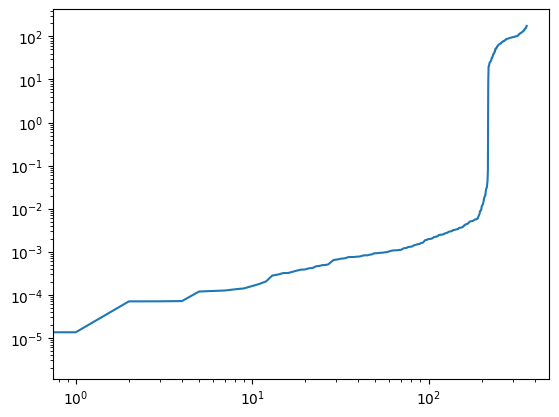

In [12]:
#seems like 0.1 pc 3D distance is quite good
plt.loglog(np.sort(sep2d[sep3d < max_sep3d]))

In [13]:
mask = sep3d < max_sep3d
mask = sep2d < max_sep2d
crossmatched = astropy.table.hstack([input[mask],pscomppars[idx[mask]], Table({"sep2d": sep2d[mask], "sep3d": sep3d[mask]})], table_names=["i", "psc", ""])

In [14]:
crossmatched.write("crossmatched.txt", format="ascii.tab", overwrite=True)

In [15]:
crossmatched.keys()

['star_name',
 'sy_dist_i',
 'st_spectype_i',
 'st_rad_i',
 'st_teff_i',
 'st_mass_i',
 'st_age_i',
 'ra_i',
 'dec_i',
 'sy_vmag_i',
 'sy_jmag_i',
 'sy_hmag_i',
 'sy_kmag_i',
 'known_binary_fl',
 'gaia_binary_fl',
 'WDSsep',
 'wds_deltamag',
 'objectid',
 'pl_name',
 'pl_letter',
 'hostid',
 'hostname',
 'hd_name',
 'hip_name',
 'tic_id',
 'disc_pubdate',
 'disc_year',
 'disc_method',
 'discoverymethod',
 'disc_locale',
 'disc_facility',
 'disc_instrument',
 'disc_telescope',
 'disc_refname',
 'ra_psc',
 'raerr1',
 'raerr2',
 'rasymerr',
 'rastr',
 'ra_solnid',
 'ra_reflink',
 'dec_psc',
 'decerr1',
 'decerr2',
 'decsymerr',
 'decstr',
 'dec_solnid',
 'dec_reflink',
 'glon',
 'glonerr1',
 'glonerr2',
 'glonsymerr',
 'glonstr',
 'glon_solnid',
 'glon_reflink',
 'glat',
 'glaterr1',
 'glaterr2',
 'glatsymerr',
 'glatstr',
 'glat_solnid',
 'glat_reflink',
 'elon',
 'elonerr1',
 'elonerr2',
 'elonsymerr',
 'elonstr',
 'elon_solnid',
 'elon_reflink',
 'elat',
 'elaterr1',
 'elaterr2',
 'ela

In [16]:
crossmatched[["star_name", "hostname", "pl_name", "dec_i", "ra_i", "sy_dist_i", "sep2d", "sep3d" ]]

star_name,hostname,pl_name,dec_i,ra_i,sy_dist_i,sep2d,sep3d
,,,,,,deg,pc
str29,str27,str29,float64,float64,float64,float64,float64
TIC 245873777,alf Tau,alf Tau b,16.509084,68.980213,20.43318348998774,0.00012282986912680657,4.681243928171412e-05
TIC 423088367,HD 62509,HD 62509 b,28.026137,116.328966,10.358400662937642,0.0001257463963343183,0.018400676955944193
TIC 229540730,bet UMi,bet UMi b,74.15555,222.676488,38.774718883288095,2.766339559433655e-06,2.179872437825807e-06
TIC 306349516,alf Ari,alf Ari b,23.462332,31.793405,20.21018593371059,0.00014084454547428122,4.984683731797525e-05
TIC 95431294,gam1 Leo,gam1 Leo b,19.841307,154.993377,39.88831272437176,0.00017887052516579575,0.00012517490289838337
TIC 318686860,GJ 273,GJ 273 c,5.2258,111.8521,3.786,1.1372248815573648e-05,2.1355350000002074
TIC 247985093,GJ 896 A,GJ 896 A b,19.9372,352.9689,6.2535,0.0010884995097612607,0.006721051213005787
TIC 115582980,HD 153557,HD 153557 b,47.3673,254.4734,17.9303,0.0019426749064235431,0.010916951181721767


Noticed problem with above code:
Astropy function only matches the entry with the closest coordinates, meaning each star get's assigned a maximum of 1 exoplanets
So instead we try to cross-match the catalog with the input, this should provide the wanted results, we expect more matches

Astropy function only matches the entry with the closest coordinates, meaning each star get's assigned a maximum of 1 exoplanets

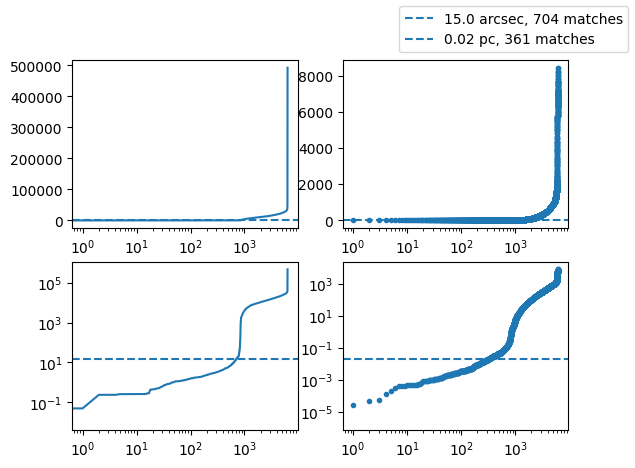

In [17]:
# can't register smaller than 10^-16 parsec (floating 
idx, sep2d, sep3d = coords_nea3d.match_to_catalog_3d(coords_input3d)
fig, axs = plt.subplots(2,2)
axs[0, 0].semilogx(np.sort(sep2d.to(u.arcsec)))
axs[1, 0].loglog(np.sort(sep2d.to(u.arcsec)))
axs[0, 1].semilogx(np.sort(sep3d[sep3d != 0].to(u.pc)),'.')
axs[1, 1].loglog(np.sort(sep3d[sep3d != 0].to(u.pc)), '.')


max_sep2d = 15*u.arcsec
axs[0,0].axhline(max_sep2d.value, linestyle='--')
axs[1,0].axhline(max_sep2d.value, linestyle='--', label=f"{max_sep2d}, {np.sum(sep2d < max_sep2d)} matches")

# proxima cen has dist. to host system of >5000 AU = 0.025	 pc
max_sep3d = 0.02*u.pc 
axs[0,1].axhline(max_sep3d.value, linestyle='--')
axs[1,1].axhline(max_sep3d.value, linestyle='--', label=f"{max_sep3d}, {np.sum(sep3d < max_sep3d)} matches")

fig.legend()

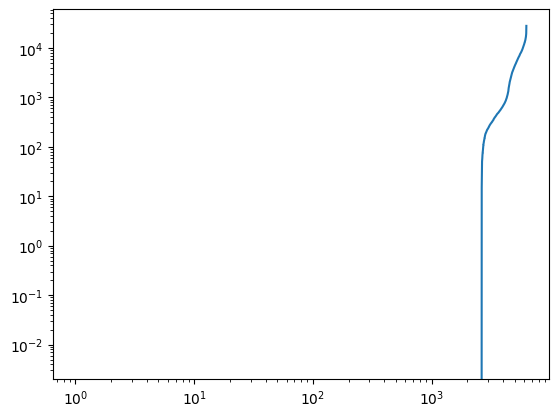

In [18]:
_, angular_dists, _ = coords_nea.match_to_catalog_sky(coords_nea, nthneighbor=2)
plt.loglog(np.sort(angular_dists.to(u.arcsec)))

In [40]:
nasa = pyvo.dal.TAPService("https://exoplanetarchive.ipac.caltech.edu/TAP")
stellarhosts = nasa.search("SELECT * FROM stellarhosts")

In [42]:
stellarhosts = stellarhosts.to_table()
stellarhosts.write("stellarhosts.txt", format="ascii", overwrite=True)

In [62]:
stellarhosts = Table.read("stellarhosts.txt", format="ascii")
stellarhosts = stellarhosts[~stellarhosts["ra"].mask & ~stellarhosts["dec"].mask]

In [63]:
coords_sthosts = SkyCoord(ra=stellarhosts["ra"], dec=stellarhosts["dec"], unit="deg")
coords_sthosts

<SkyCoord (ICRS): (ra, dec) in deg
    [(293.5777958,  46.7362953), (285.1683291,  44.0264898),
     (293.3002774,  41.5233244), ..., ( 59.4555606, -41.6320332),
     (203.3974857,  49.0608433), (168.2439697,  73.8301439)]>

In [64]:
_, input_dist, _ = coords_input.match_to_catalog_sky(coords_input, nthneighbor=2)
_, nea_stars_dist, _ = coords_sthosts.match_to_catalog_sky(coords_sthosts, nthneighbor=2)

In [65]:
input_dist.mean().to(u.arcsec), nea_stars_dist.mean().to(u.arcsec)

(<Angle 2661.91231376 arcsec>, <Angle 7.71815523 arcsec>)

In [66]:
np.median(input_dist.to(u.arcsec).value), np.median(nea_stars_dist.to(u.arcsec).value)

(np.float64(2561.5879096512626), np.float64(0.0))

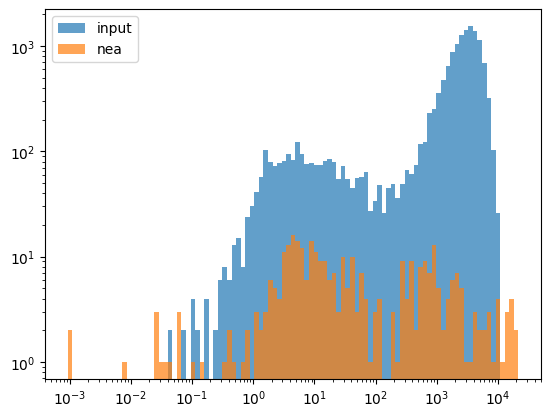

In [78]:
input_vals = input_dist.to(u.arcsec).value
nea_vals = nea_stars_dist.to(u.arcsec).value
# Filter out zero/negative values for log scale
input_vals_filtered = input_vals[input_vals > 0]
nea_vals_filtered = nea_vals[nea_vals > 0]
min_val = min(input_vals_filtered.min(), nea_vals_filtered.min())
max_val = max(input_vals_filtered.max(), nea_vals_filtered.max())
bins = np.logspace(np.log10(min_val), np.log10(max_val), 100)
plt.hist(input_vals_filtered, bins=bins, alpha=0.7, label='input')
plt.hist(nea_vals_filtered, bins=bins, alpha=0.7, label='nea')
plt.xscale('log')
plt.yscale('log')
plt.legend()